### Evaluation metrics

In [222]:
import torch
import torch.nn as nn
import torch.distributions as td
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj, to_networkx
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import argparse
import os
import networkx as nx
from collections import defaultdict, Counter

%matplotlib inline


## Mutag

In [223]:
dataset = TUDataset(root='./data/', name='MUTAG')

In [224]:
nx_graphs = []
for data in dataset:
    G = to_networkx(data, to_undirected=True)
    G = G.to_undirected()
    nx_graphs.append(G)

In [225]:
all_degrees_mutag = []
all_clustering_mutag = []
all_eigenvector_mutag = []

for i in range(len(dataset)):
    G = nx_graphs[i]

    # --- Degree ---
    degrees = [d for _, d in G.degree()]
    all_degrees_mutag.extend(degrees)

    # --- Clustering ---
    clustering = list(nx.clustering(G).values())
    all_clustering_mutag.extend(clustering)

    # --- Eigenvector centrality ---
    centrality = list(nx.eigenvector_centrality(G, max_iter=1000).values())
    all_eigenvector_mutag.extend(centrality)

## Baseline

## Samples

In [226]:
# Load CSV
df_samples = pd.read_csv("sampled_graphs.csv", header=None)

# Infer number of nodes (since adjacency is N x N)
num_cols = df_samples.shape[1]
num_nodes = int(np.sqrt(num_cols))

assert num_nodes * num_nodes == num_cols, "CSV is not a perfect square adjacency matrix!"

sample_graphs = []

for i in range(len(df_samples)):
    # reshape row → adjacency matrix
    adj = df_samples.iloc[i].values.reshape(num_nodes, num_nodes)
    adj = np.triu(adj, 1) + np.triu(adj, 1).T

    # optional: remove self-loops
    np.fill_diagonal(adj, 0)

    # convert to NetworkX graph
    G = nx.from_numpy_array(adj)
    G.remove_nodes_from(list(nx.isolates(G)))

    sample_graphs.append(G)

print(f"Converted {len(sample_graphs)} graphs")


Converted 1000 graphs


In [227]:
all_degrees_sample = []
all_clustering_sample = []
all_eigenvector_sample = []

for i in range(len(sample_graphs)):
    G = sample_graphs[i]

    # --- Degree ---
    degrees = [d for _, d in G.degree()]
    all_degrees_sample.extend(degrees)

    # --- Clustering ---
    clustering = list(nx.clustering(G).values())
    all_clustering_sample.extend(clustering)

    # --- Eigenvector centrality ---
    centrality = list(nx.eigenvector_centrality(G, max_iter=1000).values())
    all_eigenvector_sample.extend(centrality)

## Plotting

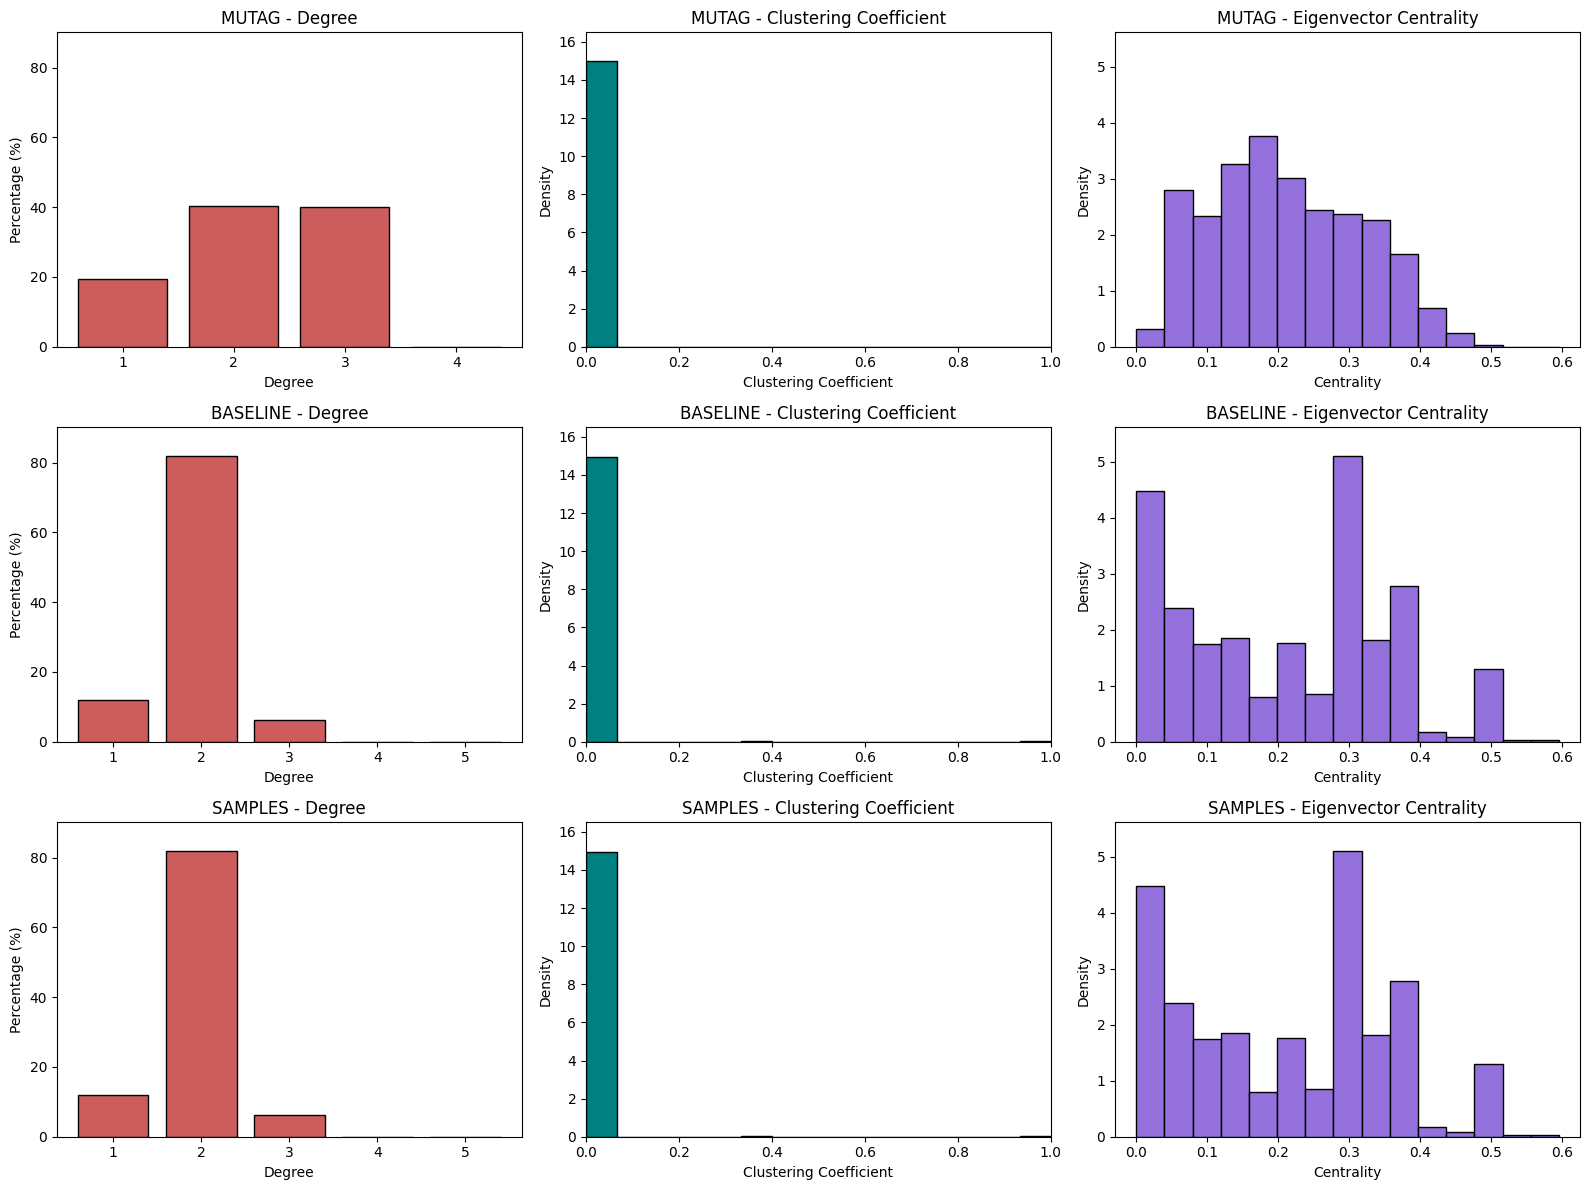

In [231]:
datasets = [
    ("MUTAG",
     all_degrees_mutag, all_clustering_mutag, all_eigenvector_mutag),
    ("BASELINE",
     all_degrees_sample, all_clustering_sample, all_eigenvector_sample),#############obs sttand in#############
    ("SAMPLES",
     all_degrees_sample, all_clustering_sample, all_eigenvector_sample),
]

# =========================
# COLORS (per metric)
# =========================
colors = ["indianred", "teal", "mediumpurple"]

# =========================
# SHARED BINS
# =========================

clust_bins = np.linspace(0, 1, 16)

eig_all = np.concatenate([eig for _, _, _, eig in datasets])
eig_bins = np.linspace(np.min(eig_all), np.max(eig_all), 16)

deg_all = np.concatenate([degs for _, degs, _, _ in datasets])
deg_bins = np.arange(0, np.max(deg_all) + 2)

# =========================
# COMPUTE GLOBAL Y-LIMITS
# =========================

deg_ys, clust_ys, eig_ys = [], [], []

for _, degs, clust, eig in datasets:

    # degree (percentage)
    deg_counts = Counter(degs)
    y = np.array(list(deg_counts.values()))
    y = y / y.sum() * 100
    deg_ys.append(np.max(y))

    # clustering density histogram
    c, _ = np.histogram(clust, bins=clust_bins, density=True)
    clust_ys.append(np.max(c))

    # eigenvector density histogram
    e, _ = np.histogram(eig, bins=eig_bins, density=True)
    eig_ys.append(np.max(e))

deg_ylim = (0, max(deg_ys) * 1.1)
clust_ylim = (0, max(clust_ys) * 1.1)
eig_ylim = (0, max(eig_ys) * 1.1)

# =========================
# FIGURE
# =========================
fig, axs = plt.subplots(3, 3, figsize=(16, 12))

for row, (name, degs, clust, eig) in enumerate(datasets):

    # =========================
    # DEGREE
    # =========================
    deg_counts = Counter(degs)
    x = sorted(deg_counts.keys())
    y = np.array([deg_counts[i] for i in x])
    y = y / y.sum() * 100

    axs[row, 0].bar(
        x, y,
        width=0.8,
        edgecolor='black',
        color=colors[0]
    )
    axs[row, 0].set_title(f"{name} - Degree")
    axs[row, 0].set_xlabel("Degree")
    axs[row, 0].set_ylabel("Percentage (%)")
    axs[row, 0].set_ylim(deg_ylim)
    axs[row, 0].set_xticks(x)

    # =========================
    # CLUSTERING
    # =========================
    axs[row, 1].hist(
        clust,
        bins=clust_bins,
        edgecolor='black',
        density=True,
        color=colors[1]
    )
    axs[row, 1].set_title(f"{name} - Clustering Coefficient")
    axs[row, 1].set_xlabel("Clustering Coefficient")
    axs[row, 1].set_ylabel("Density")
    axs[row, 1].set_xlim(0, 1)
    axs[row, 1].set_ylim(clust_ylim)

    # =========================
    # EIGENVECTOR
    # =========================
    axs[row, 2].hist(
        eig,
        bins=eig_bins,
        edgecolor='black',
        density=True,
        color=colors[2]
    )
    axs[row, 2].set_title(f"{name} - Eigenvector Centrality")
    axs[row, 2].set_xlabel("Centrality")
    axs[row, 2].set_ylabel("Density")
    axs[row, 2].set_ylim(eig_ylim)

plt.tight_layout()
plt.show()

# Novel and uniqueness

In [232]:
hashes_mutag = [
    weisfeiler_lehman_graph_hash(G, iterations=5)
    for G in nx_graphs
]
unique_hashes_mutag=set(hashes_mutag)

print("Total graphs:", len(nx_graphs))
print("Unique WL fingerprints:", len(unique_hashes_mutag))

Total graphs: 188
Unique WL fingerprints: 139


In [233]:
#Samples
hashes_sample = [
    weisfeiler_lehman_graph_hash(G, iterations=5)
    for G in sample_graphs
]
counts = Counter(hashes_sample)
is_unique = [counts[h] == 1 for h in hashes_sample]

print("Total graphs:", len(sample_graphs))
print("Unique:",sum(is_unique)/len(sample_graphs)*100,"%")

is_novel = [h not in hashes_mutag for h in hashes_sample]
print("Novel:", sum(is_novel)/1000*100,"%")

print("Novel & Unique:",sum(is_novel and is_unique)/len(sample_graphs)*100,"%")


Total graphs: 1000
Unique: 1.5 %
Novel: 100.0 %
Novel & Unique: 1.5 %
